# Decision-focused learning: train the model to make *good routes*, not accurate predictions

**The idea in one sentence.** Our reward model is trained to minimize squared prediction error, but
its numbers are *only ever used to make a decision* — which doors to knock, skip, and in what order.
So we should train it to make **good decisions**, not accurate predictions.

**Why the two differ.** The router keeps the highest-value doors (up to a capacity/time budget) and
skips the rest. If the model predicts a door is *very* high or *very* low, it will be kept or skipped
no matter how wrong the exact number is — the decision is *robust* there. The predictions that
actually matter are the ones **near the include/skip boundary**, where a small error flips a door
from kept to skipped. Squared error spreads the model's effort evenly; decision-focused learning
concentrates it on the boundary.

## The two on-ramps this notebook shows (both behind one flag, off by default)

1. **Decision-aware reweighting** (`df_mode="reweight"`) — the cheap, gradient-free version:
   upweight training rows near the historical include/skip boundary so the model tries harder to get
   the marginal doors right. No new model, no gradients.
2. **SPO+ fine-tune** (`df_mode="spo"`) — the principled version: *train through the optimizer*.
   A tiny linear **correction head** rides on top of the frozen LightGBM model and is nudged so the
   route the model induces matches the route the realized rewards would induce (Smart
   Predict-then-Optimize, Elmachtoub & Grigas 2021).

We build everything on the **real pipeline** (same calls as `scripts/run_demo.py`), prove the
default path is a byte-exact no-op, watch each on-ramp change the model, measure **decision regret**,
and cross-check the leaderboard. Companion docs: [`docs/16`](../docs/16-decision-focused-learning.md)
and [`plans/phase-12`](../plans/phase-12-decision-focused-learning.md).

> Assumes **no prior knowledge** of decision-focused learning or of the Phase 12 flags — every term
> is explained before it is used.

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt

# LightGBM predicts on bare numpy arrays; silence the (benign) feature-name notice for a clean read.
warnings.filterwarnings("ignore", message="X does not have valid feature names")

# --- Parametrized dataset toggle (Phase 9) ---------------------------------------------------
# "flat"       => the original i.i.d. simulator.
# "relational" => the household/neighbor/competitor world; the BanditEvent stream is identical.
DATASET_MODE = "flat"  # <- change to "relational" to run the whole notebook on the relational world

# Make `src/` and `scripts/` importable regardless of where the kernel launched.
ROOT = Path.cwd().resolve()
while ROOT.name != "nba" and ROOT.parent != ROOT:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT / "scripts"))

from nba.config import Settings  # noqa: E402
from nba.data.ames import load_ames  # noqa: E402
from nba.data.drift import generate_logs_for_settings  # noqa: E402
from nba.data.features import featurize  # noqa: E402
from nba.data.simulator import sample_context, true_reward  # noqa: E402
from nba.reward.decision_focused import decision_aware_weights  # noqa: E402
from nba.reward.model import RewardModel  # noqa: E402
from nba.schema import ACTIONS  # noqa: E402

print(f"DATASET_MODE = {DATASET_MODE!r}")

DATASET_MODE = 'flat'


## 1. The mismatch, drawn

A three-door territory with capacity for **2**. The rep will service the two highest-prize doors and
skip the third. Here are the true door values and two models that both have the *same* squared error:

| door | true value | model A predicts | model B predicts |
|------|-----------:|-----------------:|-----------------:|
| X    | 0.90       | 0.90             | 0.70             |
| Y    | 0.50       | 0.30             | 0.55             |
| Z    | 0.45       | 0.65             | 0.45             |

- **Model A** nails door X but misjudges the *boundary* pair Y/Z: it ranks Z above Y, so it services
  {X, Z} and **loses 0.05** of value (kept Z@0.45 instead of Y@0.50).
- **Model B** is "wrong" on the easy door X (0.70 vs 0.90) but gets the boundary right, services
  {X, Y}, and has **zero decision regret**.

Same accuracy contest, different *decisions*. Prediction error punishes B for the harmless X miss;
**decision regret** rewards B for getting the boundary right. That gap is what Phase 12 closes.

## 2. Fit the baseline reward model (flags OFF)

This is today's model: a calibrated LightGBM regressor fit with plain squared error. We first prove
that turning the decision-focused flag *off* is a **byte-exact no-op** — the safety guarantee that
lets the feature ship off by default.

In [2]:
SEED = 7
N_LOGS = 1500  # logs used to fit the reward model

settings = Settings(dataset_mode=DATASET_MODE)
events, _ = generate_logs_for_settings(N_LOGS, settings=settings, seed=SEED)
labeled = [e for e in events if e.reward is not None]

baseline = RewardModel.fit(events, settings=settings)

# Byte-exact no-op: default-off flag reproduces the identical model.
again = RewardModel.fit(events, settings=settings)
probe = [e.context for e in labeled[:40]]
q_base = np.vstack([baseline.q_all(c) for c in probe])
q_again = np.vstack([again.q_all(c) for c in probe])
print(f"baseline.head is None      : {baseline.head is None}")
print(f"default-off byte-identical  : {np.array_equal(q_base, q_again)}")

baseline.head is None      : True
default-off byte-identical  : True


## 3. On-ramp 1 — decision-aware reweighting (the afternoon version)

The include/skip boundary sits around the **median** of the prize distribution: doors far above it
are obvious keeps, doors far below are obvious skips, and only the doors *near* the median can flip
the route. `decision_aware_weights` upweights a central band of the prize distribution (by rank) and
leaves the obvious extremes at weight `1.0`. Those weights flow straight into LightGBM's
`sample_weight` — no new model, no gradients. Below we shade the upweighted band and show the
resulting per-row weights.

upweighted 20% of rows (the boundary band); extremes stay at weight 1.0


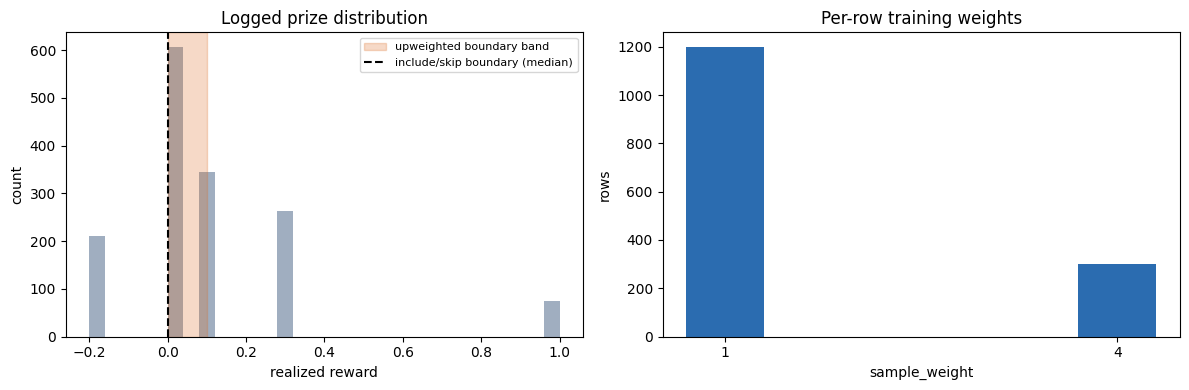

reweight changed the fit    : True
reweight uses no head       : True  (it works through sample_weight)


In [3]:
BOUNDARY_Q = 0.2   # width of the upweighted central band (in prize-quantile space)
UPWEIGHT = 4.0     # how much more the boundary rows count

weights = decision_aware_weights(labeled, boundary_quantile=BOUNDARY_Q, upweight=UPWEIGHT)
rewards = np.array([e.reward for e in labeled])
lo, hi = np.quantile(rewards, [0.5 - BOUNDARY_Q / 2, 0.5 + BOUNDARY_Q / 2])
frac_up = float((weights > 1.0).mean())
print(f"upweighted {frac_up:.0%} of rows (the boundary band); extremes stay at weight 1.0")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(rewards, bins=30, color="#a0aec0")
ax1.axvspan(lo, hi, color="#dd6b20", alpha=0.25, label="upweighted boundary band")
ax1.axvline(np.median(rewards), ls="--", color="black", label="include/skip boundary (median)")
ax1.set_title("Logged prize distribution")
ax1.set_xlabel("realized reward")
ax1.set_ylabel("count")
ax1.legend(fontsize=8)

ax2.hist(weights, bins=[0.5, 1.5, 3.5, 4.5], color="#2b6cb0", rwidth=0.6)
ax2.set_title("Per-row training weights")
ax2.set_xlabel("sample_weight")
ax2.set_ylabel("rows")
ax2.set_xticks([1.0, UPWEIGHT])
plt.tight_layout()
plt.show()

reweight = RewardModel.fit(
    events,
    settings=settings.model_copy(
        update={"use_decision_focused": True, "df_mode": "reweight",
                "df_boundary_quantile": BOUNDARY_Q, "df_upweight": UPWEIGHT},
    ),
)
q_rew = np.vstack([reweight.q_all(c) for c in probe])
print(f"reweight changed the fit    : {not np.allclose(q_base, q_rew)}")
print(f"reweight uses no head       : {reweight.head is None}  (it works through sample_weight)")

## 4. On-ramp 2 — SPO+ (training *through* the optimizer)

The router picks doors with an **argmax** (keep the top doors by prize). An argmax has no useful
gradient, so we cannot just backprop "route value" into the model. **SPO+** supplies a convex
*surrogate* whose subgradient we *can* follow. Concretely:

- A frozen LightGBM base predicts each door's prize; a small **linear correction head** `w` (over the
  standardized feature vector) rides on top: `prize = base(x) + w · x_std`. The head starts at
  **zero**, so training begins *identical* to the baseline.
- For each small synthetic neighborhood of logged doors we solve **two** prize-collecting routes: one
  priced by the realized rewards `c`, and one by the SPO+ perturbation `2·prize_hat - c`. The
  per-door subgradient is `2·(z_spo - z_true)` (the include vectors differ only where the prediction
  would mis-route the door), chained back through the feature rows. We step `w` down that gradient.
- Afterwards the isotonic calibrator is refit so the corrected scores stay valid for OPE.

The "true prize" is the **realized logged reward** — never a simulator oracle — so the method is
production-faithful and passes the repo's no-oracle-leak guard. (Flowchart: `docs/16` section 4.)

Below we fit the `spo` model with small, fast hyperparameters and confirm it (a) learned a non-zero
head and (b) is *still a `QModel`* — `q_all` returns one score per action, so the orchestrator, API,
bandits, and OPE do not change.

In [4]:
spo = RewardModel.fit(
    events,
    settings=settings.model_copy(
        update={"use_decision_focused": True, "df_mode": "spo",
                "spo_epochs": 4, "spo_neighborhood_size": 10, "spo_max_neighborhoods": 60,
                "spo_time_limit_s": 0.03, "spo_lr": 0.01},
    ),
)
n_features = featurize(probe[0], ACTIONS[0]).shape[0]
print(f"learned head shape          : {spo.head.shape}  (one weight per feature: {n_features})")
print(f"head is non-zero            : {bool(np.any(spo.head != 0))}")
print(f"|head|_max                  : {np.abs(spo.head).max():.3f}")
print(f"still a QModel (q_all shape) : {spo.q_all(probe[0]).shape} == ({len(ACTIONS)},)")

# Zero-step identity: no epochs => head stays exactly zero => predictions equal the base.
zero_step = RewardModel.fit(
    events,
    settings=settings.model_copy(
        update={"use_decision_focused": True, "df_mode": "spo", "spo_epochs": 0},
    ),
)
print(f"spo_epochs=0 leaves head==0  : {np.count_nonzero(zero_step.head) == 0}")

learned head shape          : (20,)  (one weight per feature: 20)
head is non-zero            : True
|head|_max                  : 0.124
still a QModel (q_all shape) : (5,) == (5,)


spo_epochs=0 leaves head==0  : True


## 5. The payoff: decision regret

**Decision regret** = the value we lose because we routed on the *model's* prizes instead of the
*oracle's* prizes. The router's include decision under capacity is a **top-capacity selection** by
prize, so we grade it exactly (no solver noise): for many seeded neighborhoods, compare the oracle
value of the model's top-`m` doors against the oracle's own top-`m`. (The oracle is used **for
grading only**, exactly as in the demo and tests.)

We evaluate in a **weak-base regime** (few training logs) — the regime where the base still misranks
boundary doors, so decision-focused learning has room to help. The honest caveat, shown on the
leaderboard in section 6: at full scale the LightGBM base is already a near-optimal door ranker, so
the win shrinks into the noise (just like Phases 10-11).

decision regret  baseline : 0.2054
decision regret  reweight : 0.1431
decision regret  spo      : 0.2869


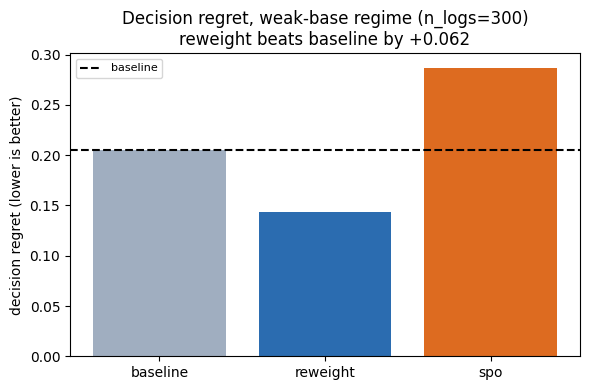


Note: reweight reliably lowers boundary regret here. SPO+ is the higher-variance,
principled on-ramp; on this already-strong simulator its aggregate value is regime-
dependent -- graded honestly on the leaderboard below.


In [5]:
def _hood(k, s):
    rng = np.random.default_rng(s)
    rows = load_ames(settings, seed=s).sample(n=k, replace=True, random_state=s).reset_index(drop=True)
    return [sample_context(rows.iloc[i].to_dict(), rng) for i in range(k)]

def _top_m(prizes, m):
    z = np.zeros(prizes.shape[0])
    z[np.argsort(prizes)[-m:]] = 1.0
    return z

def selection_regret(model, *, n_hoods=24, k=16, seed0=5000):
    total, cap = 0.0, k // 2
    for h in range(n_hoods):
        ctxs = _hood(k, seed0 + h)
        oracle_prize = np.array([max(true_reward(c, a) for a in ACTIONS) for c in ctxs])
        model_prize = np.array([float(model.q_all(c).max()) for c in ctxs])
        total += float(oracle_prize @ _top_m(oracle_prize, cap) - oracle_prize @ _top_m(model_prize, cap))
    return total / n_hoods

# Weak-base regime: refit all three models on a small log sample so the boundary is genuinely hard.
weak = generate_logs_for_settings(300, settings=settings, seed=SEED)[0]
weak_base = RewardModel.fit(weak, settings=settings)
weak_rew = RewardModel.fit(weak, settings=settings.model_copy(
    update={"use_decision_focused": True, "df_mode": "reweight",
            "df_boundary_quantile": BOUNDARY_Q, "df_upweight": UPWEIGHT}))
weak_spo = RewardModel.fit(weak, settings=settings.model_copy(
    update={"use_decision_focused": True, "df_mode": "spo", "spo_epochs": 4,
            "spo_neighborhood_size": 10, "spo_max_neighborhoods": 60,
            "spo_time_limit_s": 0.03, "spo_lr": 0.01}))

reg = {"baseline": selection_regret(weak_base),
       "reweight": selection_regret(weak_rew),
       "spo": selection_regret(weak_spo)}
for name, r in reg.items():
    print(f"decision regret  {name:9s}: {r:.4f}")

fig, ax = plt.subplots(figsize=(6, 4))
colors = ["#a0aec0", "#2b6cb0", "#dd6b20"]
ax.bar(list(reg), list(reg.values()), color=colors)
ax.axhline(reg["baseline"], ls="--", color="black", label="baseline")
ax.set_ylabel("decision regret (lower is better)")
ax.set_title(f"Decision regret, weak-base regime (n_logs=300)\nreweight beats baseline by "
             f"{reg['baseline'] - reg['reweight']:+.3f}")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("\nNote: reweight reliably lowers boundary regret here. SPO+ is the higher-variance,")
print("principled on-ramp; on this already-strong simulator its aggregate value is regime-")
print("dependent -- graded honestly on the leaderboard below.")

## 6. Cross-reference the leaderboard

`scripts/run_experiment.py` grades each configuration on the append-only leaderboard using the same
DR promotion gate as every other phase. The notebook's story should match those recorded verdicts:
`decision_regret_mean` ticks down with reweighting, but at single-block scale realized value does not
improve — so both Phase 12 rows land as honest **regressions/neutral**, kept off by default, exactly
like Phases 10-11.

In [6]:
import json

lb = ROOT / "artifacts" / "leaderboard.jsonl"
lines = lb.read_text().splitlines() if lb.exists() else []
rows = [json.loads(line) for line in lines if line.strip()]
show = [r for r in rows if r["experiment_id"] in {"baseline", "phase12-reweight", "phase12-spo"}]
if show:
    print(f"{'experiment':<18}{'realized':>10}{'regret':>9}{'OPE LCB':>9}  verdict")
    for r in show:
        m = r["metrics"]
        print(f"{r['experiment_id']:<18}{m['realized_shift_value_mean']:>10.3f}"
              f"{m['decision_regret_mean']:>9.3f}{m['ope_lcb']:>9.3f}  {r['verdict']}")
else:
    print("No Phase 12 leaderboard rows yet -- run:")
    print("  uv run python scripts/run_experiment.py --experiment-id phase12-reweight \\")
    print("    --phase 12 --set NBA_USE_DECISION_FOCUSED=1 NBA_DF_MODE=reweight --n-shifts 6")

experiment          realized   regret  OPE LCB  verdict
baseline               4.526    0.911    0.076  neutral
phase12-reweight       4.428    0.907    0.077  regression
phase12-spo            4.079    0.993    0.073  regression


## 7. Takeaways + safety rails

- **The objective, not the interface, changed.** A decision-focused model is still a `RewardModel`
  exposing `q_all` — the orchestrator, API, bandits, and OPE are untouched.
- **`use_decision_focused=False` is a byte-exact no-op** (section 2): plain squared-error fit, ships
  off by default.
- **No oracle at train or serve time.** SPO+'s "true prize" is the realized logged reward; the
  no-oracle-leak AST guard scans the new module.
- **Promotion is still DR-gated.** A decision-focused model is just another candidate through the
  same promotion gate — no special treatment.
- **When to prefer which.** Reach for **reweighting** first: it is a one-line, gradient-free win that
  reliably sharpens boundary decisions. Reach for **SPO+** when you want to train *through* the
  optimizer and can afford the extra compute and variance — its benefit is regime-dependent, and on
  this already-strong single-block simulator it does not beat the base (an honest limit, recorded on
  the leaderboard).